# Assessment Cheat Sheet — Topic-Based Quick Reference

**How to use:** Search (Cmd+F) for the topic you need. Each section is self-contained.

| Part | Sections |
|------|----------|
| **PART 1 — Setup** | 1. Imports · 2. Loading Data · 3. Exploring Data · 4. Splitting · 5. Scaling |
| **PART 2 — Models** | 6. Logistic Regression · 7. Decision Tree · 8. Random Forest · 9. KNN · 10. SVM · 11. Linear Regression |
| **PART 3 — Evaluation** | 12. Evaluating Models · 13. Comparing & Selecting · 14. Cross-Validation |
| **PART 4 — Plotting** | 15. All plot templates |
| **PART 5 — Concepts** | 16. Quick Reference Tables · 17. Writing Templates |

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Regression models
from sklearn.linear_model import LinearRegression

# Metrics
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                              f1_score, precision_score, recall_score,
                              mean_squared_error, r2_score)

np.random.seed(42)

## 2. Loading Data
Load CSV, check shape/dtypes/missing values, handle missing values, encode categoricals.

In [2]:
# --- Load CSV ---
df = pd.read_csv('data.csv')
print(f"Shape: {df.shape}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values per column:\n{df.isnull().sum()}")

# --- Handle missing values (uncomment if needed) ---
# df = df.dropna()                                    # drop rows with any NaN
# df['col'] = df['col'].fillna(df['col'].mean())      # fill NaN with column mean
# df['col'] = df['col'].fillna(df['col'].median())    # fill NaN with column median

# --- One-hot encode categorical columns (uncomment if needed) ---
# cat_cols = df.select_dtypes(include='object').columns.tolist()
# print(f"Categorical columns: {cat_cols}")
# df = pd.get_dummies(df, columns=cat_cols)

# --- Option B: Image files (like Lab 6) ---
# import glob
# from PIL import Image
# filelist = glob.glob("data/*/*.png")
# X = np.array([np.array(Image.open(f)).flatten() for f in filelist])
# y = np.array([int(f.split('/')[-2]) for f in filelist])
# X = X / 255.0  # scale pixels to [0,1]

# --- Separate features and target ---
X = df.drop('target', axis=1)
y = df['target'].values
feature_names = X.columns
X = X.values
print(f"\nX: {X.shape}, y: {y.shape}")
print(f"\nClass distribution:\n{pd.Series(y).value_counts().sort_index()}")

Shape: (1000, 9)

Data types:
age          int64
income       int64
score_1    float64
score_2    float64
score_3    float64
rating     float64
hours      float64
level      float64
target       int64
dtype: object

Missing values per column:
age        0
income     0
score_1    0
score_2    0
score_3    0
rating     0
hours      0
level      0
target     0
dtype: int64

X: (1000, 8), y: (1000,)

Class distribution:
0    499
1    300
2    201
Name: count, dtype: int64


## 3. Exploring Data
Quick exploration commands for any dataset.

In [3]:
print(df.head())
print()
print(df.describe())
print()
df.info()

   age  income   score_1   score_2   score_3    rating  hours     level  \
0   67   33704 -0.386055  1.273946 -1.007912 -2.072020   27.8 -0.757764   
1   55   64706  0.627414 -1.177698 -0.697719 -1.432949   27.8 -0.526672   
2   34   53801  2.888090 -2.126230 -0.091076  1.511700   24.7  1.805184   
3   78   89653  0.160636 -2.590576  1.673364  1.764068   14.1 -3.958327   
4   37   44550 -1.595063  0.873169  0.434941 -0.048028   16.5  0.133937   

   target  
0       1  
1       1  
2       0  
3       0  
4       2  

               age         income      score_1      score_2      score_3  \
count  1000.000000    1000.000000  1000.000000  1000.000000  1000.000000   
mean     54.666000   58399.999000     0.542364    -0.368928    -0.039891   
std      14.243642   20859.126401     1.531545     1.902424     1.010368   
min      18.000000   15000.000000    -4.255356    -7.220293    -2.899514   
25%      46.000000   44354.000000    -0.440047    -1.647630    -0.693693   
50%      55.000000  

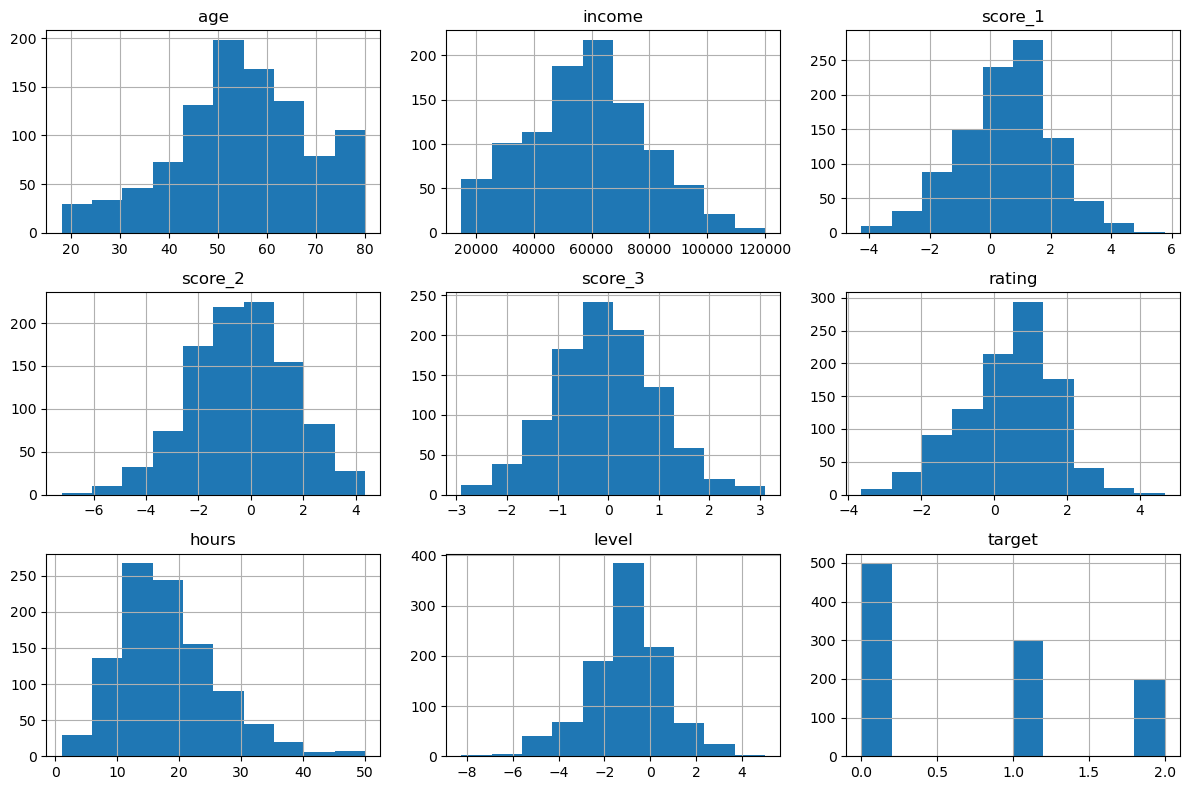

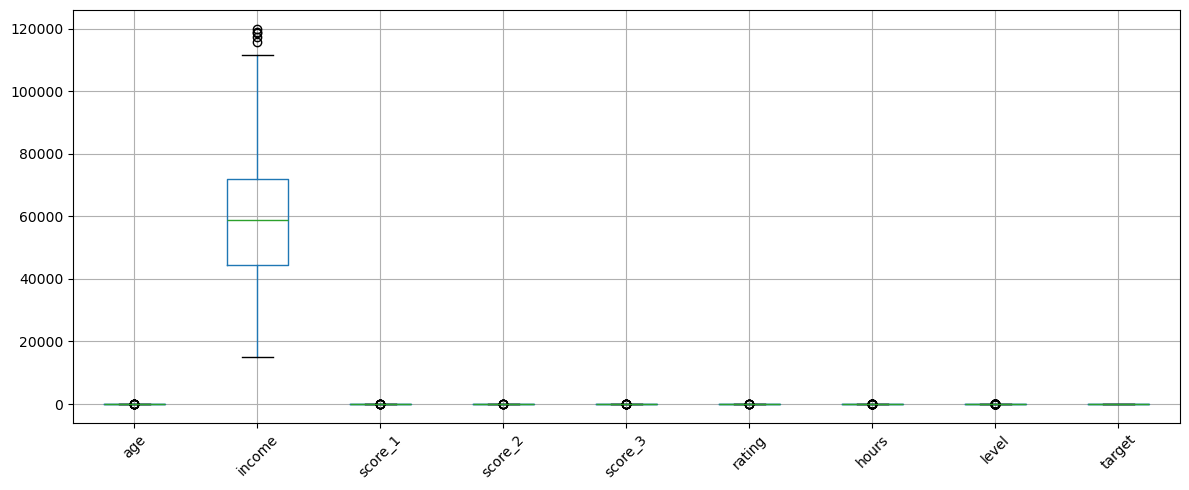

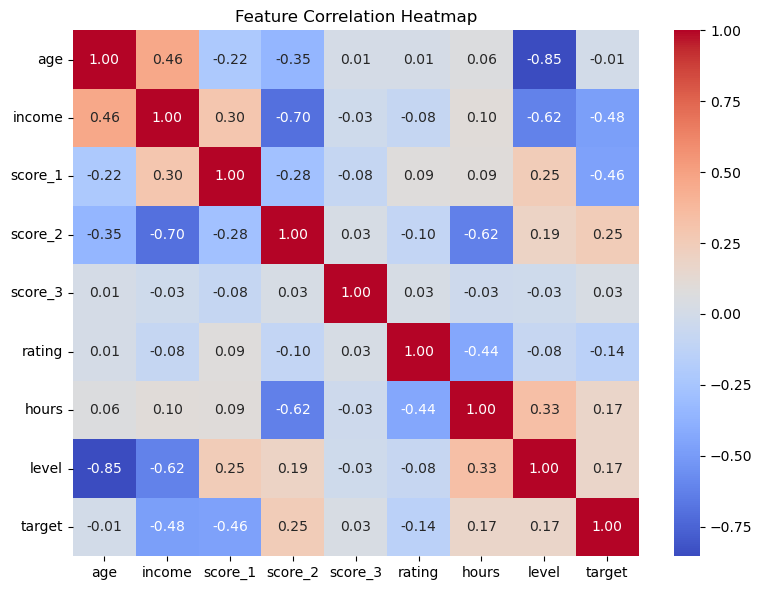

In [4]:
# Histograms — feature distributions
df.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

# Boxplots — spot outliers
df.boxplot(figsize=(12, 5))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Correlation heatmap (seaborn)
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

## 4. Splitting Data
**Split BEFORE scaling** to prevent data leakage.
`stratify=y` keeps class proportions equal across splits.
Use the **same split for all models** so comparison is fair.

**Custom split formula:** `second_test_size = val_fraction / (1 - test_fraction)`

| Desired Split | 1st `test_size` | 2nd `test_size` | Check |
|:---:|:---:|:---:|:---:|
| **60/20/20** | 0.20 | 0.25 | 0.25 × 0.80 = 0.20 |
| **50/30/20** | 0.20 | 0.375 | 0.375 × 0.80 = 0.30 |
| **70/15/15** | 0.15 | 0.176 | 0.176 × 0.85 ≈ 0.15 |

In [5]:
# === 60/20/20 three-way split (train / val / test) ===
# Use when tuning hyperparameters with a separate validation set
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)
# 0.25 x 0.80 = 0.20 -> gives 60/20/20
print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

Train: 600, Val: 200, Test: 200


In [6]:
# === Alternative: 80/20 two-way split (train / test) ===
# Use when doing cross-validation instead of a fixed validation set
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.20, random_state=42, stratify=y
# )
# print(f"Train: {X_train.shape[0]}, Test: {X_test.shape[0]}")

## 5. Scaling Data
**`fit_transform` on TRAIN only**, then `transform` on val/test. This prevents data leakage.

| Model | Needs Scaling? | Why |
|-------|:-:|-----|
| KNN | **YES** | Distance-based — large features dominate |
| Logistic Regression | **YES** | Gradient descent converges faster |
| SVM | **YES** | Margin calculations affected by scale |
| Decision Tree | NO | Threshold-based — scale doesn't matter |
| Random Forest | NO | Ensemble of decision trees |
| Linear Regression | **YES** | Coefficient magnitudes affected |

**Pipeline**: Required when doing cross-validation with scaling (see Section 14).

In [7]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)    # fit + transform on TRAIN only
X_val = scaler.transform(X_val)            # transform only (no fit!)
X_test = scaler.transform(X_test)          # transform only (no fit!)
print(f"Scaled — Train mean: {X_train.mean():.2f}, std: {X_train.std():.2f}")

Scaled — Train mean: -0.00, std: 1.00


---\n# PART 2 — MODEL REFERENCE CARDS\nEach model section is self-contained: train → accuracy → tune → model-specific features.

## 6. Logistic Regression

| | |
|---|---|
| **Needs scaling** | YES |
| **Hyperparameters** | `C` (regularisation: high C = less regularisation = more complex) |
| **Strengths** | Fast, interpretable coefficients, good baseline, predict_proba |
| **Weaknesses** | Linear decision boundaries only |
| **Key concepts** | Sigmoid function: σ(z) = 1 / (1 + e^(-z)) maps linear output → probability [0,1]. At z=0, σ=0.5 (decision boundary). Despite name, it's a classifier not a regressor. |

In [8]:
# --- Train Logistic Regression ---
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

lr_train_acc = lr.score(X_train, y_train)
lr_val_acc = lr.score(X_val, y_val)
print(f"LR Train Accuracy: {lr_train_acc:.4f}")
print(f"LR Val Accuracy:   {lr_val_acc:.4f}")
print(f"Overfitting Gap:   {lr_train_acc - lr_val_acc:.4f}")

LR Train Accuracy: 0.9417
LR Val Accuracy:   0.9400
Overfitting Gap:   0.0017


In [9]:
# --- Tune C with GridSearchCV ---
lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    {'C': [0.001, 0.01, 0.1, 1, 10, 100]},
    cv=5, scoring='accuracy', n_jobs=-1
)
lr_grid.fit(X_train, y_train)
print(f"Best C: {lr_grid.best_params_['C']}, CV Acc: {lr_grid.best_score_:.4f}")

# Retrain with best C
best_lr = LogisticRegression(C=lr_grid.best_params_['C'], max_iter=1000, random_state=42)
best_lr.fit(X_train, y_train)
print(f"Tuned Val Accuracy: {best_lr.score(X_val, y_val):.4f}")

Best C: 10, CV Acc: 0.9383
Tuned Val Accuracy: 0.9450


predict_proba (first 3 samples):
[[0.9811 0.0133 0.0056]
 [0.8059 0.1906 0.0035]
 [0.     1.     0.    ]]


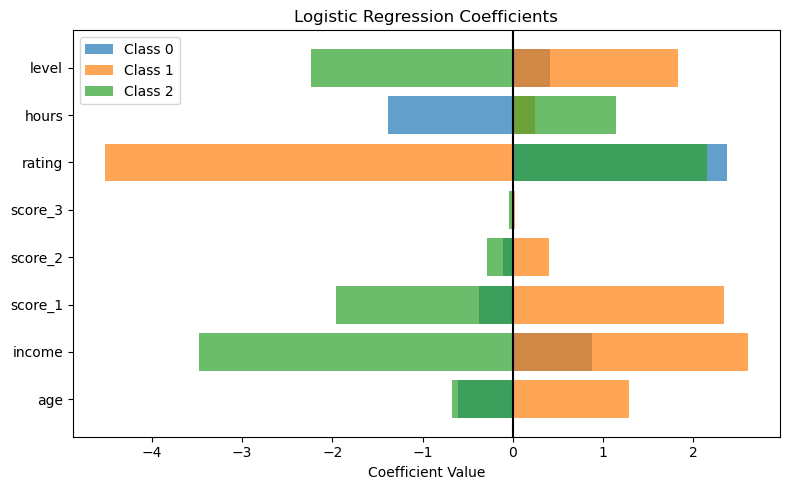

In [10]:
# --- Coefficients & predict_proba ---
# predict_proba -> probability for each class
y_proba = best_lr.predict_proba(X_val)[:3]
print("predict_proba (first 3 samples):")
print(y_proba.round(4))

# Coefficient plot (shows feature influence)
plt.figure(figsize=(8, 5))
for i in range(best_lr.coef_.shape[0]):
    plt.barh(feature_names, best_lr.coef_[i], alpha=0.7, label=f'Class {i}')
plt.axvline(x=0, color='black', linestyle='-')
plt.xlabel('Coefficient Value')
plt.title('Logistic Regression Coefficients')
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
# --- For imbalanced data: use scoring='f1_macro' ---
lr_grid_f1 = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    {'C': [0.001, 0.01, 0.1, 1, 10, 100]},
    cv=5, scoring='f1_macro', n_jobs=-1  # f1_macro for multi-class, f1 for binary
)
lr_grid_f1.fit(X_train, y_train)
print(f"Best C (F1 macro): {lr_grid_f1.best_params_['C']}, Score: {lr_grid_f1.best_score_:.4f}")

Best C (F1 macro): 10, Score: 0.9325


## 7. Decision Tree

| | |
|---|---|
| **Needs scaling** | NO |
| **Hyperparameters** | `max_depth`, `min_samples_split`, `min_samples_leaf` |
| **Strengths** | Interpretable, no scaling needed, handles nonlinearity, feature_importances_ |
| **Weaknesses** | Prone to overfitting, axis-aligned (rectangular) decision boundaries |
| **Key concepts** | Splits data with "is feature > threshold?" questions. Deeper trees = more complex = more overfitting risk. `min_samples_split` / `min_samples_leaf` = more regularisation. |

In [12]:
# --- Train Decision Tree ---
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

dt_train_acc = dt.score(X_train, y_train)
dt_val_acc = dt.score(X_val, y_val)
print(f"DT Train Accuracy: {dt_train_acc:.4f}")
print(f"DT Val Accuracy:   {dt_val_acc:.4f}")
print(f"Overfitting Gap:   {dt_train_acc - dt_val_acc:.4f}")

DT Train Accuracy: 0.9183
DT Val Accuracy:   0.8550
Overfitting Gap:   0.0633


In [13]:
# --- Tune with GridSearchCV ---
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    {
        'max_depth': [3, 5, 7, 10],
        'min_samples_split': [2, 10, 20],
        'min_samples_leaf': [1, 5, 10]
    },
    cv=5, scoring='accuracy', n_jobs=-1
)
dt_grid.fit(X_train, y_train)
print(f"Best params: {dt_grid.best_params_}")
print(f"Best CV Accuracy: {dt_grid.best_score_:.4f}")

# Retrain with best params
best_dt = DecisionTreeClassifier(**dt_grid.best_params_, random_state=42)
best_dt.fit(X_train, y_train)
print(f"Tuned Val Accuracy: {best_dt.score(X_val, y_val):.4f}")

Best params: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best CV Accuracy: 0.9117
Tuned Val Accuracy: 0.8900


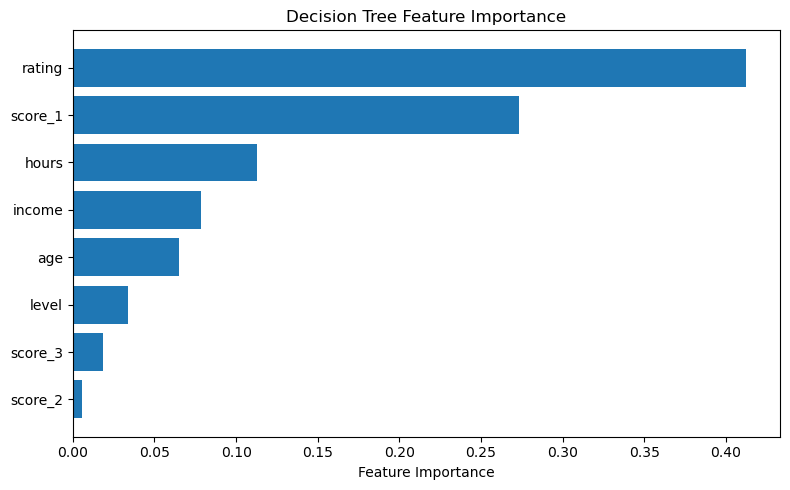

In [14]:
# --- Feature Importances ---
importances = best_dt.feature_importances_
sorted_idx = np.argsort(importances)
plt.figure(figsize=(8, 5))
plt.barh(feature_names[sorted_idx], importances[sorted_idx])
plt.xlabel('Feature Importance')
plt.title('Decision Tree Feature Importance')
plt.tight_layout()
plt.show()

## 8. Random Forest

| | |
|---|---|
| **Needs scaling** | NO |
| **Hyperparameters** | `n_estimators` (number of trees), `max_depth` |
| **Strengths** | Powerful, reduces overfitting vs single tree, feature_importances_ |
| **Weaknesses** | Slower to train, less interpretable than single tree |
| **Key concepts** | Ensemble of decision trees. Each tree trained on random subset of data/features. Aggregates via **majority voting**. |

**Random Forest vs Decision Tree:** RF = many trees → majority vote → less overfitting, more robust.

In [15]:
# --- Train Random Forest ---
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

rf_train_acc = rf.score(X_train, y_train)
rf_val_acc = rf.score(X_val, y_val)
print(f"RF Train Accuracy: {rf_train_acc:.4f}")
print(f"RF Val Accuracy:   {rf_val_acc:.4f}")
print(f"Overfitting Gap:   {rf_train_acc - rf_val_acc:.4f}")

RF Train Accuracy: 1.0000
RF Val Accuracy:   0.9550
Overfitting Gap:   0.0450


In [16]:
# --- Tune with GridSearchCV ---
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    {
        'n_estimators': [50, 100, 200],
        'max_depth': [10, 20, 30, None]
    },
    cv=5, scoring='accuracy', n_jobs=-1
)
rf_grid.fit(X_train, y_train)
print(f"Best params: {rf_grid.best_params_}")
print(f"Best CV Accuracy: {rf_grid.best_score_:.4f}")

# Retrain with best params
best_rf = RandomForestClassifier(**rf_grid.best_params_, random_state=42, n_jobs=-1)
best_rf.fit(X_train, y_train)
print(f"Tuned Val Accuracy: {best_rf.score(X_val, y_val):.4f}")

Best params: {'max_depth': 20, 'n_estimators': 100}
Best CV Accuracy: 0.9483
Tuned Val Accuracy: 0.9550


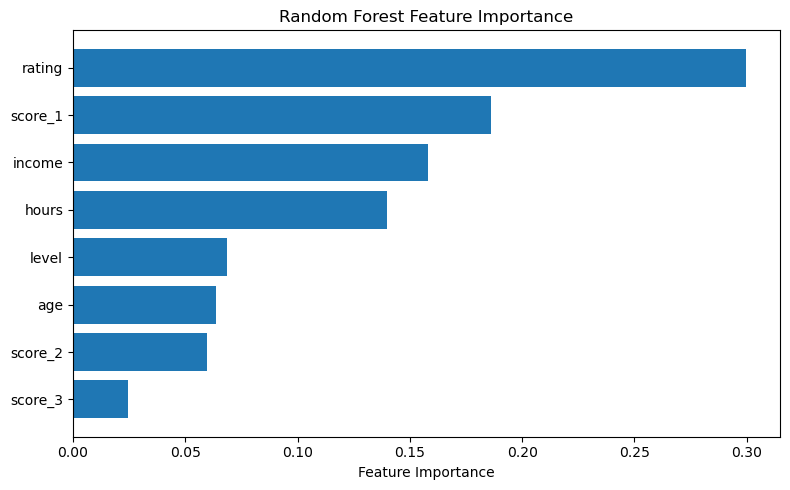

In [17]:
# --- Feature Importances ---
importances = best_rf.feature_importances_
sorted_idx = np.argsort(importances)
plt.figure(figsize=(8, 5))
plt.barh(feature_names[sorted_idx], importances[sorted_idx])
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

## 9. KNN (K-Nearest Neighbours)

| | |
|---|---|
| **Needs scaling** | **YES — MUST scale** (distance-based, large features dominate) |
| **Hyperparameters** | `n_neighbors` (k) |
| **Strengths** | Simple, no training phase, nonlinear boundaries |
| **Weaknesses** | Slow prediction on large data, sensitive to scale and irrelevant features |
| **Key concepts** | "Lazy learner" — stores all training data, computes distances at prediction time. k=1 overfits (100% train acc). k too large underfits (majority voter). Lab 4 showed ~21% improvement from scaling. |

**Why scaling is critical:** Without scaling, `income` (range 15000–120000) dominates `rating` (range -4 to 5). Nearest neighbours determined almost entirely by income.

In [18]:
# --- Train KNN ---
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_train, y_train)

knn_train_acc = knn.score(X_train, y_train)
knn_val_acc = knn.score(X_val, y_val)
print(f"KNN Train Accuracy: {knn_train_acc:.4f}")
print(f"KNN Val Accuracy:   {knn_val_acc:.4f}")
print(f"Overfitting Gap:    {knn_train_acc - knn_val_acc:.4f}")

KNN Train Accuracy: 0.9583
KNN Val Accuracy:   0.9300
Overfitting Gap:    0.0283


In [19]:
# --- Tune k with GridSearchCV ---
# Using Pipeline ensures proper scaling inside each CV fold
knn_pipe = make_pipeline(StandardScaler(), KNeighborsClassifier(n_jobs=-1))
knn_grid = GridSearchCV(
    knn_pipe,
    {'kneighborsclassifier__n_neighbors': list(range(1, 16))},
    cv=5, scoring='accuracy', n_jobs=-1
)
knn_grid.fit(X_train, y_train)
best_k = knn_grid.best_params_['kneighborsclassifier__n_neighbors']
print(f"Best k: {best_k}, CV Acc: {knn_grid.best_score_:.4f}")

# Retrain with best k (data already scaled from Section 5)
best_knn = KNeighborsClassifier(n_neighbors=best_k, n_jobs=-1)
best_knn.fit(X_train, y_train)
print(f"Tuned Val Accuracy: {best_knn.score(X_val, y_val):.4f}")

Best k: 3, CV Acc: 0.9433
Tuned Val Accuracy: 0.9300


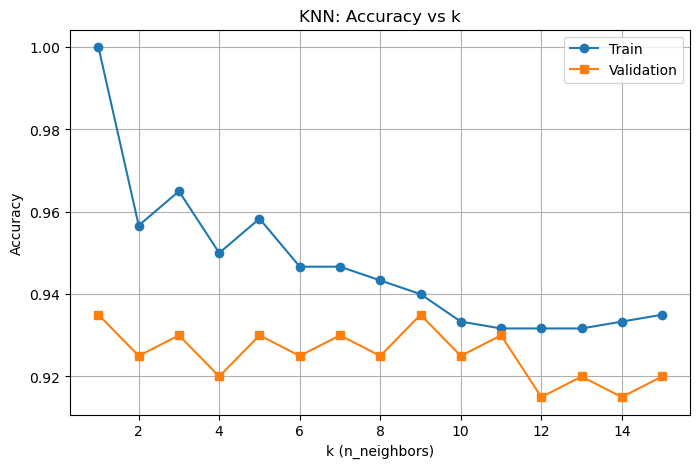

In [20]:
# --- Accuracy vs k plot ---
k_values = list(range(1, 16))
k_train_scores = []
k_val_scores = []

for k in k_values:
    m = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    m.fit(X_train, y_train)
    k_train_scores.append(m.score(X_train, y_train))
    k_val_scores.append(m.score(X_val, y_val))

plt.figure(figsize=(8, 5))
plt.plot(k_values, k_train_scores, 'o-', label='Train')
plt.plot(k_values, k_val_scores, 's-', label='Validation')
plt.xlabel('k (n_neighbors)')
plt.ylabel('Accuracy')
plt.title('KNN: Accuracy vs k')
plt.legend()
plt.grid(True)
plt.show()

## 10. SVM (Linear)

| | |
|---|---|
| **Needs scaling** | **YES — MUST scale** (margin calculations affected, very slow unscaled) |
| **Hyperparameters** | `C` (same as LR: high C = less regularisation) |
| **Strengths** | Strong on high-dimensional data, effective with clear margins |
| **Weaknesses** | Slow on large datasets, no probability estimates by default |
| **Key concepts** | Finds hyperplane that maximises margin between classes. Linear kernel = linear boundaries. |

In [21]:
# --- Train SVM ---
svm = SVC(kernel='linear', random_state=42)
svm.fit(X_train, y_train)

svm_train_acc = svm.score(X_train, y_train)
svm_val_acc = svm.score(X_val, y_val)
print(f"SVM Train Accuracy: {svm_train_acc:.4f}")
print(f"SVM Val Accuracy:   {svm_val_acc:.4f}")
print(f"Overfitting Gap:    {svm_train_acc - svm_val_acc:.4f}")

SVM Train Accuracy: 0.9733
SVM Val Accuracy:   0.9350
Overfitting Gap:    0.0383


In [22]:
# --- Tune C with GridSearchCV ---
svm_grid = GridSearchCV(
    SVC(kernel='linear', random_state=42),
    {'C': [0.001, 0.01, 0.1, 1, 10, 100]},
    cv=5, scoring='accuracy', n_jobs=-1
)
svm_grid.fit(X_train, y_train)
print(f"Best C: {svm_grid.best_params_['C']}, CV Acc: {svm_grid.best_score_:.4f}")

# Retrain with best C
best_svm = SVC(kernel='linear', C=svm_grid.best_params_['C'], random_state=42)
best_svm.fit(X_train, y_train)
print(f"Tuned Val Accuracy: {best_svm.score(X_val, y_val):.4f}")

Best C: 10, CV Acc: 0.9717
Tuned Val Accuracy: 0.9300


## 11. Linear Regression (Regression Problems)

| | |
|---|---|
| **Needs scaling** | YES (coefficient magnitudes affected) |
| **Hyperparameters** | None (ordinary least squares) |
| **Strengths** | Fast, interpretable, coefficients show feature effects |
| **Weaknesses** | Only for continuous targets, assumes linear relationship |
| **Key metrics** | R², Adjusted R², RMSE |
| **Key concepts** | `reshape(-1,1)` for single feature. Check correlation before modelling. |

**Note:** This section treats `target` as continuous for demonstration. In a real regression task, the target would be a continuous variable (price, temperature, etc.).

In [23]:
# --- Train Linear Regression ---
lr_reg = LinearRegression()
lr_reg.fit(X_train, y_train)
y_train_pred_reg = lr_reg.predict(X_train)
y_val_pred_reg = lr_reg.predict(X_val)

# Metrics
r2_train = r2_score(y_train, y_train_pred_reg)
r2_val = r2_score(y_val, y_val_pred_reg)
n = len(y_val)
p = X_val.shape[1]  # number of features
adj_r2 = 1 - (1 - r2_val) * (n - 1) / (n - p - 1)
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred_reg))

print(f"Train R\u00b2:     {r2_train:.4f}")
print(f"Val R\u00b2:       {r2_val:.4f}")
print(f"Adjusted R\u00b2:  {adj_r2:.4f}")
print(f"RMSE:         {rmse:.4f}")

# Coefficients
print(f"\nIntercept: {lr_reg.intercept_:.4f}")
print("Coefficients:")
for name, coef in zip(feature_names, lr_reg.coef_):
    print(f"  {name}: {coef:.4f}")

Train R²:     0.4273
Val R²:       0.4229
Adjusted R²:  0.3987
RMSE:         0.5933

Intercept: 0.7033
Coefficients:
  age: -0.1205
  income: -0.6817
  score_1: -0.1360
  score_2: -0.1819
  score_3: -0.0011
  rating: -0.1263
  hours: 0.1828
  level: -0.3781


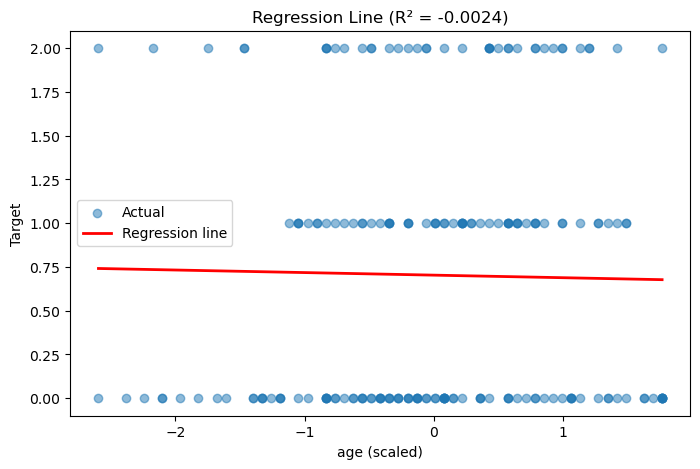

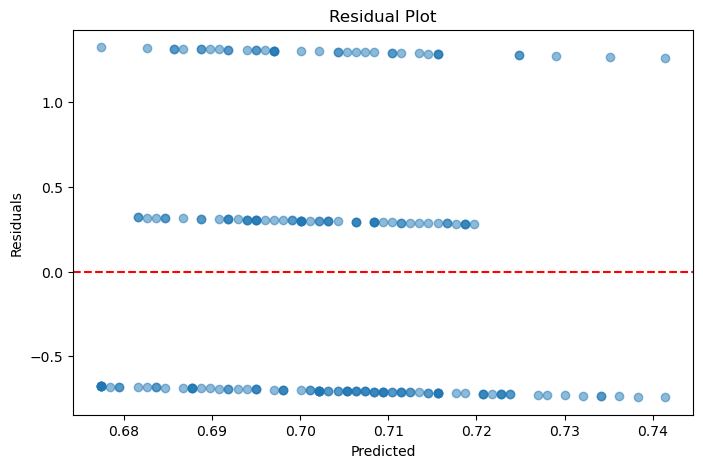

In [24]:
# --- Single-feature regression (reshape required) ---
# reshape(-1,1) converts 1D array to 2D column for sklearn
X_single_train = X_train[:, 0].reshape(-1, 1)
X_single_val = X_val[:, 0].reshape(-1, 1)

lr_single = LinearRegression()
lr_single.fit(X_single_train, y_train)
y_single_pred = lr_single.predict(X_single_val)

# Regression line plot
plt.figure(figsize=(8, 5))
plt.scatter(X_single_val, y_val, alpha=0.5, label='Actual')
sort_idx = X_single_val.flatten().argsort()
plt.plot(X_single_val[sort_idx], y_single_pred[sort_idx], color='red', linewidth=2, label='Regression line')
plt.xlabel(f'{feature_names[0]} (scaled)')
plt.ylabel('Target')
plt.title(f'Regression Line (R\u00b2 = {r2_score(y_val, y_single_pred):.4f})')
plt.legend()
plt.show()

# Residual plot
residuals = y_val - y_single_pred
plt.figure(figsize=(8, 5))
plt.scatter(y_single_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

In [25]:
# --- Correlation check ---
print("Correlation matrix:")
print(df.corr().round(3))

Correlation matrix:
           age  income  score_1  score_2  score_3  rating  hours  level  \
age      1.000   0.464   -0.222   -0.349    0.012   0.010  0.059 -0.855   
income   0.464   1.000    0.296   -0.701   -0.029  -0.085  0.098 -0.619   
score_1 -0.222   0.296    1.000   -0.278   -0.084   0.087  0.092  0.249   
score_2 -0.349  -0.701   -0.278    1.000    0.027  -0.096 -0.623  0.190   
score_3  0.012  -0.029   -0.084    0.027    1.000   0.026 -0.031 -0.026   
rating   0.010  -0.085    0.087   -0.096    0.026   1.000 -0.439 -0.076   
hours    0.059   0.098    0.092   -0.623   -0.031  -0.439  1.000  0.334   
level   -0.855  -0.619    0.249    0.190   -0.026  -0.076  0.334  1.000   
target  -0.006  -0.479   -0.464    0.249    0.033  -0.142  0.169  0.173   

         target  
age      -0.006  
income   -0.479  
score_1  -0.464  
score_2   0.249  
score_3   0.033  
rating   -0.142  
hours     0.169  
level     0.173  
target    1.000  


---\n# PART 3 — EVALUATION & SELECTION

## 12. Evaluating Models
Confusion matrix, classification report, precision/recall/F1/accuracy.

**Confusion matrix layout:**
```
                Predicted Neg    Predicted Pos
Actual Neg      True Negative    False Positive (Type I error)
Actual Pos      False Negative   True Positive  (Type II error)
```

| Metric | Formula | When to use |
|--------|---------|-------------|
| **Precision** | TP / (TP + FP) | "Of predicted positives, how many correct?" — spam filtering |
| **Recall** | TP / (TP + FN) | "Of actual positives, how many caught?" — disease screening |
| **F1** | 2 × (P × R) / (P + R) | Balanced metric when both matter |
| **Accuracy** | (TP + TN) / Total | Misleading if classes are imbalanced |

Confusion Matrix:
[[97  2  1]
 [ 3 57  0]
 [ 2  1 37]]


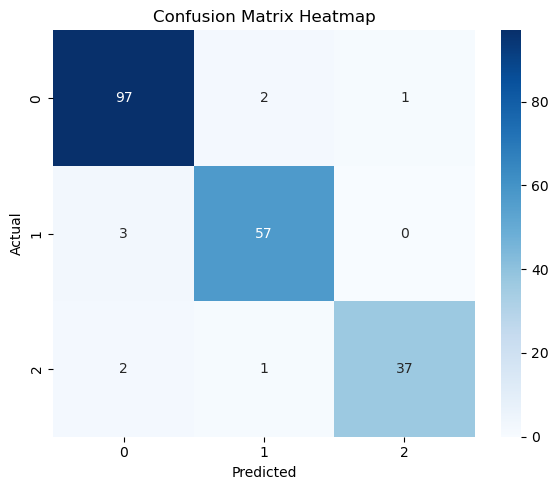


Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       100
           1       0.95      0.95      0.95        60
           2       0.97      0.93      0.95        40

    accuracy                           0.95       200
   macro avg       0.96      0.95      0.95       200
weighted avg       0.96      0.95      0.95       200



In [26]:
# --- Confusion Matrix (print + heatmap) ---
y_val_pred = best_rf.predict(X_val)

cm = confusion_matrix(y_val, y_val_pred)
print("Confusion Matrix:")
print(cm)

# Heatmap plot
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(set(y)), yticklabels=sorted(set(y)))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.tight_layout()
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

In [27]:
# --- Class imbalance handling ---

# Option 1: Use scoring='f1_macro' in GridSearchCV (multi-class)
grid_f1 = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    {'C': [0.01, 0.1, 1, 10]},
    cv=5, scoring='f1_macro', n_jobs=-1  # f1_macro for multi-class, f1 for binary
)
grid_f1.fit(X_train, y_train)
print(f"Best C (F1 macro): {grid_f1.best_params_['C']}, Score: {grid_f1.best_score_:.4f}")

# Option 2: Use class_weight='balanced'
lr_balanced = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_balanced.fit(X_train, y_train)
print(f"\nWith class_weight='balanced':")
print(f"  Train Acc: {lr_balanced.score(X_train, y_train):.4f}")
print(f"  Val Acc:   {lr_balanced.score(X_val, y_val):.4f}")
print("\nWARNING: class_weight='balanced' can cause precision collapse (Lab 5).")
print("Always check confusion matrix after using it.")

Best C (F1 macro): 10, Score: 0.9325

With class_weight='balanced':
  Train Acc: 0.9517
  Val Acc:   0.9350

Always check confusion matrix after using it.


## 13. Comparing & Selecting Models
Compare all tuned models on validation set → pick best → combine train+val → retrain → test ONCE.

In [28]:
# --- Compare tuned models on validation set ---
tuned_models = {
    f"LR (C={lr_grid.best_params_['C']})": best_lr,
    f"DT ({dt_grid.best_params_})": best_dt,
    f"RF ({rf_grid.best_params_})": best_rf,
    f"KNN (k={best_k})": best_knn,
    f"SVM (C={svm_grid.best_params_['C']})": best_svm,
}

print("=== Tuned Model Validation Accuracy ===")
scores = {}
for name, model in tuned_models.items():
    acc = model.score(X_val, y_val)
    scores[name] = acc
    print(f"  {name}: {acc:.4f}")

best_name = max(scores, key=scores.get)
print(f"\nBest: {best_name} -> {scores[best_name]:.4f}")

=== Tuned Model Validation Accuracy ===
  LR (C=10): 0.9450
  DT ({'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10}): 0.8900
  RF ({'max_depth': 20, 'n_estimators': 100}): 0.9550
  KNN (k=3): 0.9300
  SVM (C=10): 0.9300

Best: RF ({'max_depth': 20, 'n_estimators': 100}) -> 0.9550


In [29]:
# --- Final evaluation: combine train+val, re-scale, retrain, test ONCE ---
X_combined = np.vstack([X_train, X_val])
y_combined = np.concatenate([y_train, y_val])

# Re-scale (fit on combined, transform test)
scaler_final = StandardScaler()
X_combined = scaler_final.fit_transform(X_combined)
X_test_final = scaler_final.transform(X_test)

print(f"Combined train+val: {X_combined.shape[0]} samples")

# >>> CHANGE THIS to match whichever model won above <<<
final_model = RandomForestClassifier(**rf_grid.best_params_, random_state=42, n_jobs=-1)
final_model.fit(X_combined, y_combined)

# Evaluate ONCE on test
y_test_pred = final_model.predict(X_test_final)
print(f"\nTest Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_test_pred)}")
print(f"\nClassification Report:\n{classification_report(y_test, y_test_pred)}")

Combined train+val: 800 samples

Test Accuracy: 0.9500

Confusion Matrix:
[[98  2  0]
 [ 4 56  0]
 [ 4  0 36]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       100
           1       0.97      0.93      0.95        60
           2       1.00      0.90      0.95        40

    accuracy                           0.95       200
   macro avg       0.96      0.94      0.95       200
weighted avg       0.95      0.95      0.95       200



## 14. Cross-Validation
- **cross_val_score**: Quick eval of a single model with k-fold CV
- **GridSearchCV**: Tries all hyperparameter combos with CV
- **Pipeline**: Required when scaling inside CV folds (KNN, LR, SVM)

**Key attributes:** `grid.best_params_`, `grid.best_score_`, `grid.best_estimator_`

In [30]:
# --- cross_val_score (quick evaluation) ---
cv_scores = cross_val_score(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1
)
print(f"CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print(f"Individual folds: {cv_scores.round(4)}")

CV Accuracy: 0.9483 (+/- 0.0178)
Individual folds: [0.925  0.9583 0.9333 0.975  0.95  ]


In [31]:
# --- Pipeline with GridSearchCV (proper scaling inside CV) ---
# REQUIRED for models that need scaling (KNN, LR, SVM) when using cross-validation
# Pipeline ensures fit_transform on train fold, transform on val fold (no leakage)
pipe = make_pipeline(StandardScaler(), KNeighborsClassifier(n_jobs=-1))
param_grid = {'kneighborsclassifier__n_neighbors': range(1, 16)}
# Note: param name format is lowercase_classname__param

grid_pipe = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_pipe.fit(X_train, y_train)
print(f"Best k: {grid_pipe.best_params_}")
print(f"Best CV Accuracy: {grid_pipe.best_score_:.4f}")

Best k: {'kneighborsclassifier__n_neighbors': 3}
Best CV Accuracy: 0.9433


---\n# PART 4 — PLOTTING

## 15. Plotting Reference
Copy-paste templates for common assessment plots.

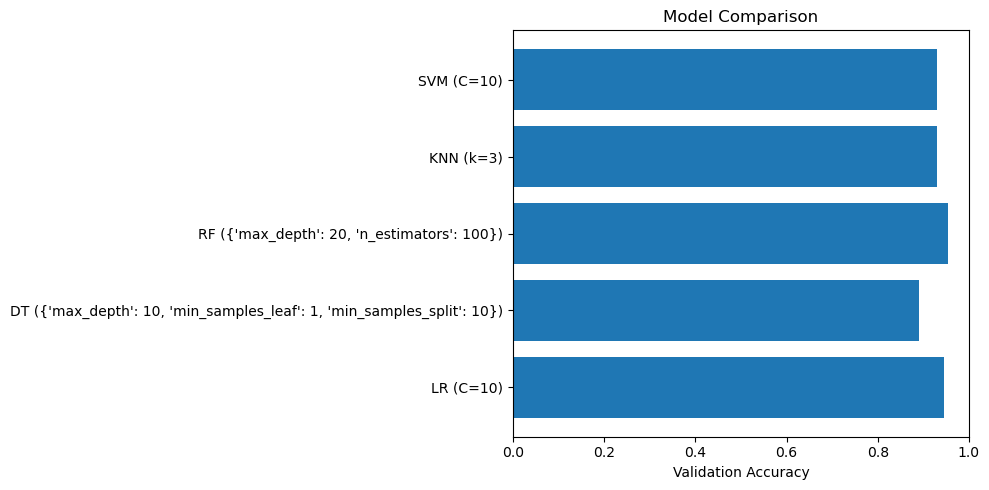

In [32]:
# --- Bar chart: model comparison ---
model_names = list(scores.keys())
model_scores = list(scores.values())

plt.figure(figsize=(10, 5))
plt.barh(model_names, model_scores)
plt.xlabel('Validation Accuracy')
plt.title('Model Comparison')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

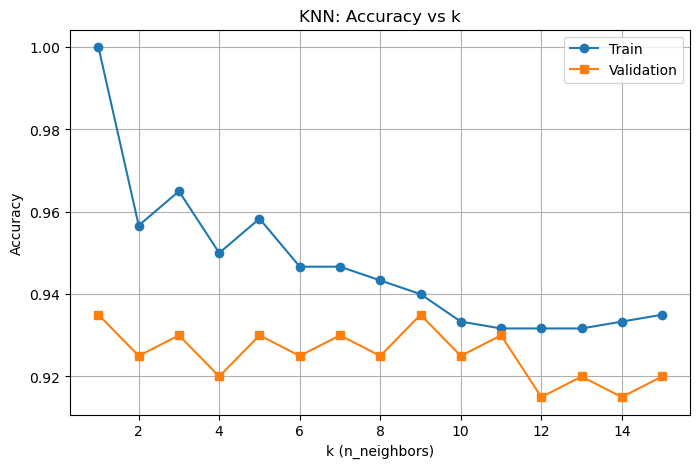

In [33]:
# --- Accuracy vs hyperparameter (e.g. K for KNN) ---
plt.figure(figsize=(8, 5))
plt.plot(k_values, k_train_scores, 'o-', label='Train')
plt.plot(k_values, k_val_scores, 's-', label='Validation')
plt.xlabel('k (n_neighbors)')
plt.ylabel('Accuracy')
plt.title('KNN: Accuracy vs k')
plt.legend()
plt.grid(True)
plt.show()

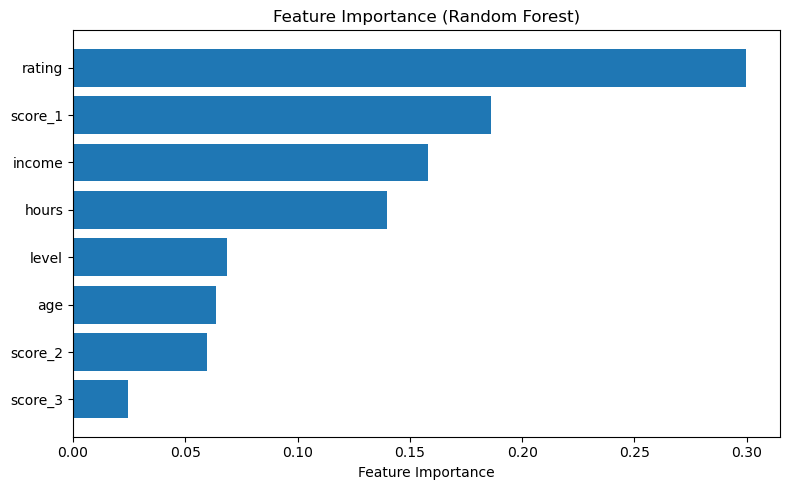

In [34]:
# --- Feature importance bar chart ---
importances = best_rf.feature_importances_
sorted_idx = np.argsort(importances)

plt.figure(figsize=(8, 5))
plt.barh(feature_names[sorted_idx], importances[sorted_idx])
plt.xlabel('Feature Importance')
plt.title('Feature Importance (Random Forest)')
plt.tight_layout()
plt.show()

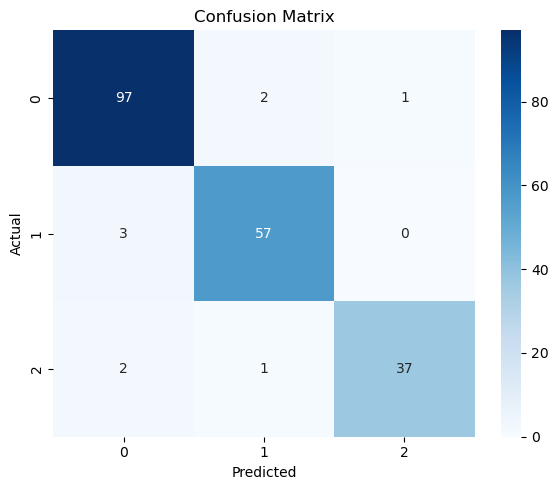

In [35]:
# --- Confusion matrix heatmap ---
cm = confusion_matrix(y_val, best_rf.predict(X_val))
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(set(y)), yticklabels=sorted(set(y)))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

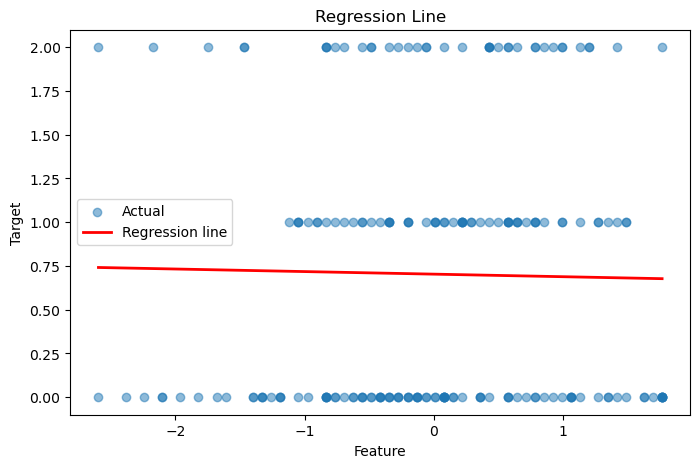

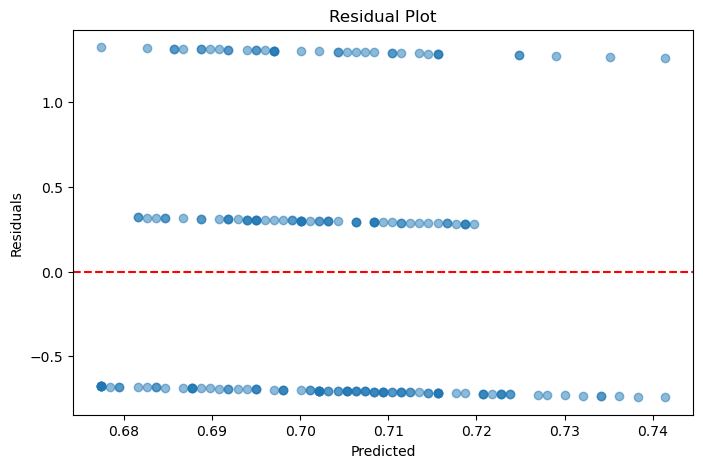

In [36]:
# --- Regression line plot ---
plt.figure(figsize=(8, 5))
plt.scatter(X_single_val, y_val, alpha=0.5, label='Actual')
sort_idx = X_single_val.flatten().argsort()
plt.plot(X_single_val[sort_idx], y_single_pred[sort_idx], 'r-', linewidth=2, label='Regression line')
plt.xlabel('Feature')
plt.ylabel('Target')
plt.title('Regression Line')
plt.legend()
plt.show()

# --- Residual plot ---
residuals = y_val - y_single_pred
plt.figure(figsize=(8, 5))
plt.scatter(y_single_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

---\n# PART 5 — KEY CONCEPTS (for written answers)

## 16. Quick Reference Concepts

### Overfitting vs Underfitting

| | Overfitting | Underfitting |
|---|---|---|
| **Symptom** | Train acc high, val acc much lower | Both train and val acc low |
| **Cause** | Model too complex, memorises training data | Model too simple, can't capture patterns |
| **Fix** | Reduce max_depth, increase min_samples, lower C, get more data | Increase max_depth, increase C, add features, use more complex model |

### C Parameter (Logistic Regression & SVM)

| C value | Regularisation | Complexity | Risk |
|---------|:-:|:-:|:-:|
| **High C** (100) | Less | More complex | Overfitting |
| **Low C** (0.001) | More | Simpler | Underfitting |

High C = model allowed to be more complex to fit data.

### Scaling — When & Why

| Model | Scaling? | Why |
|-------|:-:|-----|
| **KNN** | YES | Distance-based — feature with range 0–100k dominates feature with range 0–1 |
| **Logistic Regression** | YES | Gradient descent converges faster |
| **SVM** | YES | Margin calculations affected — unscaled = very slow |
| **Decision Tree** | NO | Threshold-based — "is feature > X?" unaffected by scale |
| **Random Forest** | NO | Ensemble of decision trees |

Always `fit_transform` on train, then `transform` only on val/test to prevent data leakage.

### Class Imbalance
- **Accuracy is misleading** with imbalanced classes (99% class A → always predict A = 99% accuracy)
- Use **F1-score**, precision, recall instead
- `scoring='f1_macro'` (multi-class) or `scoring='f1'` (binary) in GridSearchCV
- `class_weight='balanced'` can help but may cause **precision collapse** (Lab 5: precision dropped 0.891 → 0.102)
- Always check the **confusion matrix**

### Data Leakage
- Scaling before splitting → val/test sees training statistics → leaked
- Fix: split first, then fit_transform on train only, transform on val/test
- In CV: use Pipeline so scaling happens inside each fold

### Train / Validation / Test — Why Three Sets?

| Set | Purpose | When |
|-----|---------|------|
| **Train** (60%) | Fit the model | Every `.fit()` call |
| **Validation** (20%) | Tune hyperparameters, compare models | After training, before final eval |
| **Test** (20%) | Final unbiased evaluation | **ONCE** at the very end |

Use same split for all models so comparison is fair.
When best model chosen: combine train+val, retrain, evaluate on test.

### One-Hot Encoding (Categorical Features)
```python
# Check for categorical columns
cat_cols = df.select_dtypes(include='object').columns
# Create binary columns for each category
df = pd.get_dummies(df, columns=cat_cols)
# 'colour' [red, blue, green] -> colour_red, colour_blue, colour_green (0/1)
```
Apply **before** train/test split so all sets have the same columns.

### Forward Feature Selection
Iteratively add features one at a time, keeping those that improve validation accuracy.
Requires X as **DataFrames** (not `.values`) to select columns by name.

```python
selected = []
remaining = list(X_train_df.columns)
best_acc = 0
while remaining:
    best_feature, best_acc_round = None, 0
    for feature in remaining:
        trial = selected + [feature]
        scaler_fs = StandardScaler()
        X_tr = scaler_fs.fit_transform(X_train_df[trial])
        X_va = scaler_fs.transform(X_val_df[trial])
        model = LogisticRegression(max_iter=1000)
        model.fit(X_tr, y_train)
        acc = accuracy_score(y_val, model.predict(X_va))
        if acc > best_acc_round:
            best_acc_round = acc
            best_feature = feature
    if best_acc_round > best_acc:
        best_acc = best_acc_round
        selected.append(best_feature)
        remaining.remove(best_feature)
    else:
        break
```

### Model Strengths & Weaknesses Summary

| Model | Strengths | Weaknesses | Scaling? | Hyperparams |
|-------|-----------|------------|:-:|------------|
| **Logistic Regression** | Fast, interpretable, coefficients, predict_proba | Linear boundaries only | YES | C |
| **Decision Tree** | Interpretable, no scaling, feature importance | Overfits easily, rectangular boundaries | NO | max_depth, min_samples_split/leaf |
| **Random Forest** | Powerful, reduces DT overfitting, feature importance | Slower, less interpretable | NO | n_estimators, max_depth |
| **KNN** | Simple, no training, nonlinear boundaries | Slow prediction, scale-sensitive | YES | n_neighbors |
| **SVM (linear)** | Strong high-dimensional, effective margins | Slow on large data, no probabilities default | YES | C |
| **Linear Regression** | Fast, interpretable coefficients | Continuous targets only, assumes linearity | YES | — |

## 17. Writing Templates

### Commenting on a trained model:
> The [model] achieved [X]% training accuracy and [Y]% validation accuracy, giving a gap of [Z]%.
> This [small/large] gap indicates [minimal overfitting / significant overfitting].
> [Why — e.g. "Random Forests with defaults grow trees to full depth, so 100% train accuracy is expected"].
> Tuning [hyperparameter] via cross-validation should help [reduce overfitting / improve performance].

### Model selection justification:
> The best model was [Model Name] with [hyperparameters], achieving a validation accuracy of [X]%.
> This outperformed [other models] because [reason — e.g. "ensemble averaging reduces overfitting", "nonlinear boundaries capture the pattern"].

### Confusion matrix analysis:
> Class [X] had the lowest recall at [Y]%, being most frequently confused with class [Z] ([N] times).
> This makes sense because [reason].
> Class [A] performed best with [precision/recall], likely because [distinctive features].

### Overfitting analysis:
> The gap between train ([X]%) and validation ([Y]%) accuracy is [Z]%.
> This suggests [minimal/moderate/significant] overfitting.
> To reduce overfitting: [lower max_depth / increase regularisation (lower C) / add more training data / use ensemble methods].